# Tree-Based Intelligent Intrusion Detection System in Internet of Vehicles 
This is the code for the paper entitled "[**Tree-Based Intelligent Intrusion Detection System in Internet of Vehicles**](https://arxiv.org/pdf/1910.08635.pdf)" published in IEEE GlobeCom 2019.  
Authors: Li Yang (liyanghart@gmail.com), Abdallah Moubayed, Ismail Hamieh, and Abdallah Shami  
Organization: The Optimized Computing and Communications (OC2) Lab, ECE Department, Western University

If you find this repository useful in your research, please cite:  
L. Yang, A. Moubayed, I. Hamieh and A. Shami, "Tree-Based Intelligent Intrusion Detection System in Internet of Vehicles," 2019 IEEE Global Communications Conference (GLOBECOM), 2019, pp. 1-6, doi: 10.1109/GLOBECOM38437.2019.9013892.  

## Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_recall_fscore_support
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import plot_importance

## Read the sampled CICIDS2017 dataset
The CICIDS2017 dataset is publicly available at: https://www.unb.ca/cic/datasets/ids-2017.html  
Due to the large size of this dataset, the sampled subsets of CICIDS2017 is used. The subsets are in the "data" folder.  
If you want to use this code on other datasets (e.g., CAN-intrusion dataset), just change the dataset name and follow the same steps. The models in this code are generic models that can be used in any intrusion detection/network traffic datasets.

In [4]:
#Read dataset
df = pd.read_csv('./data/CICIDS2017.csv')
# The results in this code is based on the original CICIDS2017 dataset. Please go to cell [10] if you work on the sampled dataset. 

In [5]:
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,53,32215,4,2,112,152,28,28,28.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830739,53,324,2,2,84,362,42,42,42.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830740,58030,82,2,1,31,6,31,0,15.5,21.92031,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830741,53,1048635,6,2,192,256,32,32,32.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [6]:
df.Label.value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

### Data sampling
Due to the space limit of GitHub files, we sample a small-sized subset for model learning using random sampling

In [7]:
# Sampling the dataset

# 1. BENIGN
df_BENIGN = df[df['Label'] == 'BENIGN'].sample(
    frac=0.01, random_state=0
)

# 2. DoS attacks
dos_labels = [
    'DoS Hulk',
    'DDoS',
    'DoS GoldenEye',
    'DoS slowloris',
    'DoS Slowhttptest'
]

df_DoS = df[df['Label'].isin(dos_labels)].sample(
    frac=0.05, random_state=0
)

# 3. PortScan
df_PortScan = df[df['Label'] == 'PortScan'].sample(
    frac=0.05, random_state=0
)

# 4. Brute Force attacks
bruteforce_labels = [
    'FTP-Patator',
    'SSH-Patator'
]

df_BruteForce = df[df['Label'].isin(bruteforce_labels)].sample(
    frac=0.20, random_state=0
)

# 5. Other minority attacks
df_minor = df[
    df['Label'].str.contains(
        'Web Attack|Bot|Infiltration|Heartbleed',
        case=False,
        na=False
    )
]

print("Sampling completed.")
print("BENIGN:", len(df_BENIGN))
print("DoS:", len(df_DoS))
print("PortScan:", len(df_PortScan))
print("BruteForce:", len(df_BruteForce))
print("Minor:", len(df_minor))

Sampling completed.
BENIGN: 22731
DoS: 19034
PortScan: 7946
BruteForce: 2767
Minor: 4193


In [8]:
df_s = pd.concat([
    df_BENIGN,
    df_DoS,
    df_PortScan,
    df_BruteForce,
    df_minor
], ignore_index=True)

In [9]:
print(df_s['Label'].value_counts())

Label
BENIGN                        22731
DoS Hulk                      11508
PortScan                       7946
DDoS                           6439
Bot                            1966
FTP-Patator                    1548
Web Attack � Brute Force       1507
SSH-Patator                    1219
Web Attack � XSS                652
DoS GoldenEye                   510
DoS Slowhttptest                299
DoS slowloris                   278
Infiltration                     36
Web Attack � Sql Injection       21
Heartbleed                       11
Name: count, dtype: int64


In [10]:
print("Sample dataset shape:")
print(df_s.shape)

print("\nClass distribution:")
print(df_s['Label'].value_counts())

Sample dataset shape:
(56671, 79)

Class distribution:
Label
BENIGN                        22731
DoS Hulk                      11508
PortScan                       7946
DDoS                           6439
Bot                            1966
FTP-Patator                    1548
Web Attack � Brute Force       1507
SSH-Patator                    1219
Web Attack � XSS                652
DoS GoldenEye                   510
DoS Slowhttptest                299
DoS slowloris                   278
Infiltration                     36
Web Attack � Sql Injection       21
Heartbleed                       11
Name: count, dtype: int64


In [11]:
print("Original dataset labels:")
print(df['Label'].value_counts())

Original dataset labels:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [12]:
print("\nIndividual sampled DataFrames:")

print("BENIGN:", len(df_BENIGN))
print("DoS:", len(df_DoS))
print("PortScan:", len(df_PortScan))
print("BruteForce:", len(df_BruteForce))
print("Minor:", len(df_minor))


Individual sampled DataFrames:
BENIGN: 22731
DoS: 19034
PortScan: 7946
BruteForce: 2767
Minor: 4193


In [13]:
df_s = df_s.sort_index()

In [14]:
# Save the sampled dataset
df_s.to_csv('./data/CICIDS2017_sample.csv',index=0)

In [15]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nDoes data folder exist?")
print(os.path.exists("./data"))

print("\nDoes sample file exist?")
print(os.path.exists("./data/CICIDS2017_sample.csv"))

if os.path.exists("./data/CICIDS2017_sample.csv"):
    print("\nFile found at:")
    print(os.path.abspath("./data/CICIDS2017_sample.csv"))

Current working directory:
c:\Users\Amber Sharma\Desktop\IDS

Does data folder exist?
True

Does sample file exist?
True

File found at:
c:\Users\Amber Sharma\Desktop\IDS\data\CICIDS2017_sample.csv


### Preprocessing (normalization and padding values)

In [16]:
df = pd.read_csv('./data/CICIDS2017_sample.csv')

In [17]:
# Min-max normalization

# Select only numerical features and explicitly exclude Label
numeric_features = df.select_dtypes(include='number').columns

# Apply min-max normalization
df[numeric_features] = df[numeric_features].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

# Fill empty values by 0
df = df.fillna(0)

### split train set and test set

In [18]:
print("df_s:", len(df_s))
print("df:", len(df))

df_s: 56671
df: 56671


In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Use the sampled dataset
df = df_s.copy()

# Encode the Label column
labelencoder = LabelEncoder()
df['Label'] = labelencoder.fit_transform(df['Label'].astype(str))

# Create X and y
X = df.drop(['Label'], axis=1).values
y = df['Label'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nLabel mapping:")
for number, label in enumerate(labelencoder.classes_):
    print(number, "=", label)

print("\nTraining class counts:")
print(pd.Series(y_train).value_counts().sort_index())

Training set: (45336, 78)
Testing set: (11335, 78)

Label mapping:
0 = BENIGN
1 = Bot
2 = DDoS
3 = DoS GoldenEye
4 = DoS Hulk
5 = DoS Slowhttptest
6 = DoS slowloris
7 = FTP-Patator
8 = Heartbleed
9 = Infiltration
10 = PortScan
11 = SSH-Patator
12 = Web Attack � Brute Force
13 = Web Attack � Sql Injection
14 = Web Attack � XSS

Training class counts:
0     18184
1      1573
2      5151
3       408
4      9206
5       239
6       222
7      1238
8         9
9        29
10     6357
11      975
12     1206
13       17
14      522
Name: count, dtype: int64


In [20]:
X_train.shape

(45336, 78)

In [21]:
pd.Series(y_train).value_counts()

0     18184
4      9206
10     6357
2      5151
1      1573
7      1238
12     1206
11      975
14      522
3       408
5       239
6       222
9        29
13       17
8         9
Name: count, dtype: int64

### Oversampling by SMOTE

In [22]:
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

# Check missing values
print("NaN values before cleaning:", np.isnan(X_train).sum())

# Replace NaN and infinite values
X_train = np.nan_to_num(
    X_train,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

X_test = np.nan_to_num(
    X_test,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

print("NaN values after cleaning:", np.isnan(X_train).sum())

# SMOTE: increase minority classes up to 1500 samples
class_counts = pd.Series(y_train).value_counts()

sampling_strategy = {
    cls: 1500
    for cls, count in class_counts.items()
    if count < 1500
}

print("\nSMOTE sampling strategy:")
print(sampling_strategy)

smote = SMOTE(
    sampling_strategy=sampling_strategy,
    random_state=42
)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Training set:", X_train.shape)
print("\nClass distribution:")
print(pd.Series(y_train).value_counts().sort_index())

NaN values before cleaning: 49
NaN values after cleaning: 0

SMOTE sampling strategy:
{7: 1500, 12: 1500, 11: 1500, 14: 1500, 3: 1500, 5: 1500, 6: 1500, 9: 1500, 13: 1500, 8: 1500}

After SMOTE:
Training set: (55471, 78)

Class distribution:
0     18184
1      1573
2      5151
3      1500
4      9206
5      1500
6      1500
7      1500
8      1500
9      1500
10     6357
11     1500
12     1500
13     1500
14     1500
Name: count, dtype: int64


In [23]:
X_train, y_train = smote.fit_resample(X_train, y_train)

In [24]:
pd.Series(y_train).value_counts()

0     18184
4      9206
10     6357
2      5151
1      1573
3      1500
7      1500
14     1500
5      1500
11     1500
12     1500
6      1500
13     1500
9      1500
8      1500
Name: count, dtype: int64

## Machine learning model training

### Training four base learners: decision tree, random forest, extra trees, XGBoost

Accuracy of DT: 0.9822673136303485
Precision of DT: 0.9831218628871067
Recall of DT: 0.9822673136303485
F1-score of DT: 0.9826164877043365
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4547
           1       0.99      0.98      0.98       393
           2       1.00      1.00      1.00      1288
           3       1.00      0.99      1.00       102
           4       1.00      1.00      1.00      2302
           5       0.94      0.98      0.96        60
           6       0.98      0.96      0.97        56
           7       1.00      1.00      1.00       310
           8       0.67      1.00      0.80         2
           9       0.80      0.57      0.67         7
          10       1.00      0.99      1.00      1589
          11       1.00      1.00      1.00       244
          12       0.78      0.73      0.76       301
          13       0.50      0.50      0.50         4
          14       0.44      0.52      0.48       

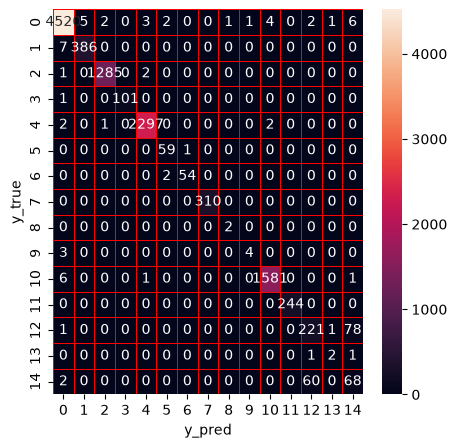

In [25]:
# Decision tree training and prediction
dt = DecisionTreeClassifier(random_state = 0)
dt.fit(X_train,y_train) 
dt_score=dt.score(X_test,y_test)
y_predict=dt.predict(X_test)
y_true=y_test
print('Accuracy of DT: '+ str(dt_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of DT: '+(str(precision)))
print('Recall of DT: '+(str(recall)))
print('F1-score of DT: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [26]:
dt_train=dt.predict(X_train)
dt_test=dt.predict(X_test)

Accuracy of RF: 0.9817379797088663
Precision of RF: 0.9814291215000828
Recall of RF: 0.9817379797088663
F1-score of RF: 0.9815095766549335
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4547
           1       0.98      0.97      0.98       393
           2       1.00      1.00      1.00      1288
           3       0.99      1.00      1.00       102
           4       1.00      1.00      1.00      2302
           5       0.97      0.98      0.98        60
           6       0.98      0.95      0.96        56
           7       1.00      1.00      1.00       310
           8       1.00      1.00      1.00         2
           9       1.00      0.57      0.73         7
          10       1.00      1.00      1.00      1589
          11       1.00      1.00      1.00       244
          12       0.73      0.74      0.74       301
          13       1.00      0.50      0.67         4
          14       0.38      0.36      0.37       

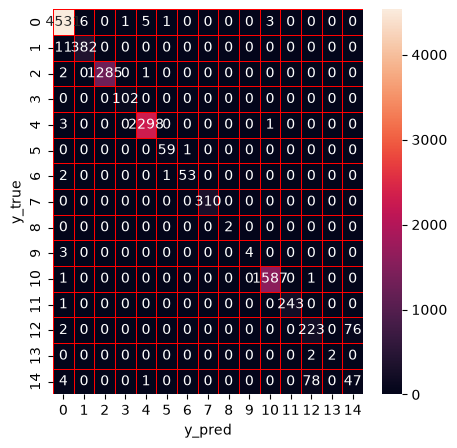

In [27]:
# Random Forest training and prediction
rf = RandomForestClassifier(random_state = 0)
rf.fit(X_train,y_train) 
rf_score=rf.score(X_test,y_test)
y_predict=rf.predict(X_test)
y_true=y_test
print('Accuracy of RF: '+ str(rf_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of RF: '+(str(precision)))
print('Recall of RF: '+(str(recall)))
print('F1-score of RF: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [28]:
rf_train=rf.predict(X_train)
rf_test=rf.predict(X_test)

Accuracy of ET: 0.9792677547419497
Precision of ET: 0.97949588868355
Recall of ET: 0.9792677547419497
F1-score of ET: 0.9793182385168038
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4547
           1       0.96      0.96      0.96       393
           2       1.00      1.00      1.00      1288
           3       0.99      0.98      0.99       102
           4       1.00      1.00      1.00      2302
           5       0.98      0.98      0.98        60
           6       0.98      0.95      0.96        56
           7       1.00      1.00      1.00       310
           8       1.00      1.00      1.00         2
           9       1.00      0.57      0.73         7
          10       1.00      1.00      1.00      1589
          11       1.00      1.00      1.00       244
          12       0.73      0.69      0.71       301
          13       0.33      0.25      0.29         4
          14       0.37      0.41      0.39       13

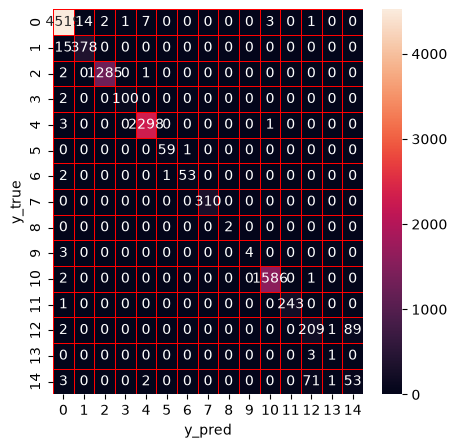

In [29]:
# Extra trees training and prediction
et = ExtraTreesClassifier(random_state = 0)
et.fit(X_train,y_train) 
et_score=et.score(X_test,y_test)
y_predict=et.predict(X_test)
y_true=y_test
print('Accuracy of ET: '+ str(et_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of ET: '+(str(precision)))
print('Recall of ET: '+(str(recall)))
print('F1-score of ET: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [30]:
et_train=et.predict(X_train)
et_test=et.predict(X_test)

Accuracy of XGBoost: 0.9810322011468902
Precision of XGBoost: 0.9829051065672231
Recall of XGBoost: 0.9810322011468902
F1-score of XGBoost: 0.9814648731231951
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4547
           1       0.99      0.97      0.98       393
           2       1.00      1.00      1.00      1288
           3       0.98      0.96      0.97       102
           4       0.99      1.00      1.00      2302
           5       0.91      0.98      0.94        60
           6       0.98      0.91      0.94        56
           7       1.00      1.00      1.00       310
           8       1.00      1.00      1.00         2
           9       1.00      0.57      0.73         7
          10       1.00      1.00      1.00      1589
          11       1.00      1.00      1.00       244
          12       0.79      0.63      0.70       301
          13       1.00      0.50      0.67         4
          14       0.41      0

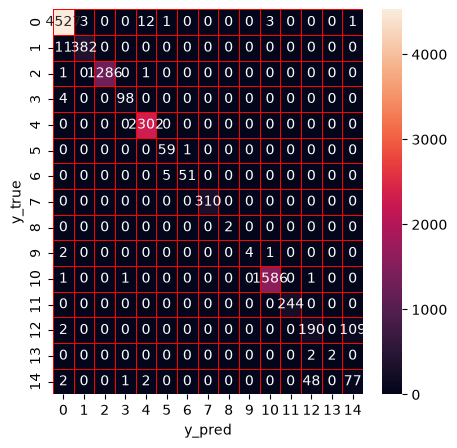

In [31]:
# XGboost training and prediction
xg = xgb.XGBClassifier(n_estimators = 10)
xg.fit(X_train,y_train)
xg_score=xg.score(X_test,y_test)
y_predict=xg.predict(X_test)
y_true=y_test
print('Accuracy of XGBoost: '+ str(xg_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [32]:
xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)

### Stacking model construction (ensemble for 4 base learners)

In [33]:
# Use the outputs of 4 base models to construct a new ensemble model
base_predictions_train = pd.DataFrame( {
    'DecisionTree': dt_train.ravel(),
        'RandomForest': rf_train.ravel(),
     'ExtraTrees': et_train.ravel(),
     'XgBoost': xg_train.ravel(),
    })
base_predictions_train.head(5)

,DecisionTree,RandomForest,ExtraTrees,XgBoost
0,3,3,3,3
1,0,0,0,0
2,2,2,2,2
3,0,0,0,0
4,10,10,10,10


In [34]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)

In [35]:
x_train = np.concatenate(( dt_train, et_train, rf_train, xg_train), axis=1)
x_test = np.concatenate(( dt_test, et_test, rf_test, xg_test), axis=1)

In [36]:
stk = xgb.XGBClassifier().fit(x_train, y_train)

Accuracy of Stacking: 0.9822673136303485
Precision of Stacking: 0.9831218628871067
Recall of Stacking: 0.9822673136303485
F1-score of Stacking: 0.9826164877043365
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4547
           1       0.99      0.98      0.98       393
           2       1.00      1.00      1.00      1288
           3       1.00      0.99      1.00       102
           4       1.00      1.00      1.00      2302
           5       0.94      0.98      0.96        60
           6       0.98      0.96      0.97        56
           7       1.00      1.00      1.00       310
           8       0.67      1.00      0.80         2
           9       0.80      0.57      0.67         7
          10       1.00      0.99      1.00      1589
          11       1.00      1.00      1.00       244
          12       0.78      0.73      0.76       301
          13       0.50      0.50      0.50         4
          14       0.44   

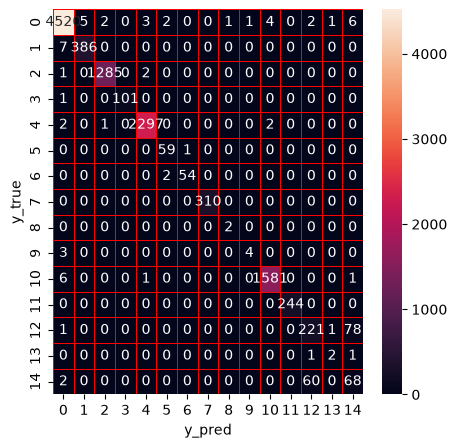

In [37]:
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

## Feature Selection

### Feature importance

In [38]:
# Save the feature importance lists generated by four tree-based algorithms
dt_feature = dt.feature_importances_
rf_feature = rf.feature_importances_
et_feature = et.feature_importances_
xgb_feature = xg.feature_importances_

In [39]:
# calculate the average importance value of each feature
avg_feature = (dt_feature + rf_feature + et_feature + xgb_feature)/4

In [40]:
feature=(df.drop(['Label'],axis=1)).columns.values
print ("Features sorted by their score:")
print (sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True))

Features sorted by their score:
[(np.float64(0.1119), 'Bwd Packet Length Min'), (np.float64(0.0729), 'Destination Port'), (np.float64(0.0707), 'Min Packet Length'), (np.float64(0.0308), 'Fwd IAT Std'), (np.float64(0.0298), 'min_seg_size_forward'), (np.float64(0.0269), 'Packet Length Mean'), (np.float64(0.0269), 'Init_Win_bytes_forward'), (np.float64(0.0263), 'PSH Flag Count'), (np.float64(0.0255), 'Init_Win_bytes_backward'), (np.float64(0.0254), 'Bwd Packet Length Std'), (np.float64(0.0237), 'Bwd Packet Length Max'), (np.float64(0.0211), 'Flow IAT Max'), (np.float64(0.02), 'act_data_pkt_fwd'), (np.float64(0.0197), 'Subflow Fwd Bytes'), (np.float64(0.0176), 'Bwd Packets/s'), (np.float64(0.0168), 'Average Packet Size'), (np.float64(0.0158), 'Bwd Packet Length Mean'), (np.float64(0.0148), 'Total Length of Bwd Packets'), (np.float64(0.0138), 'Fwd Header Length'), (np.float64(0.0136), 'Fwd IAT Mean'), (np.float64(0.0135), 'Bwd Header Length'), (np.float64(0.0129), 'Subflow Bwd Packets'), (n

In [41]:
f_list = sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True)

In [42]:
len(f_list)

78

In [43]:
# Select the important features from top-importance to bottom-importance until the accumulated importance reaches 0.9 (out of 1)
Sum = 0
fs = []
for i in range(0, len(f_list)):
    Sum = Sum + f_list[i][0]
    fs.append(f_list[i][1])
    if Sum>=0.9:
        break        

In [44]:
X_fs = df[fs].values

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X_fs,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)

In [46]:
X_train.shape

(45336, 46)

In [47]:
pd.Series(y_train).value_counts()

0     18184
4      9206
10     6357
2      5151
1      1573
7      1238
12     1206
11      975
14      522
3       408
5       239
6       222
9        29
13       17
8         9
Name: count, dtype: int64

### Oversampling by SMOTE

In [49]:
from imblearn.over_sampling import SMOTE
import numpy as np

# Check and remove NaN values
print("NaN values before cleaning:", np.isnan(X_train).sum())

X_train = np.nan_to_num(X_train, nan=0.0)

print("NaN values after cleaning:", np.isnan(X_train).sum())

# Apply SMOTE only to minority classes
smote = SMOTE(
    sampling_strategy={
        3: 1500,
        5: 1500,
        6: 1500,
        7: 1500,
        8: 1500,
        9: 1500,
        11: 1500,
        12: 1500,
        13: 1500,
        14: 1500
    },
    random_state=42
)

print("SMOTE sampling strategy:", smote.sampling_strategy)

NaN values before cleaning: 0
NaN values after cleaning: 0
SMOTE sampling strategy: {3: 1500, 5: 1500, 6: 1500, 7: 1500, 8: 1500, 9: 1500, 11: 1500, 12: 1500, 13: 1500, 14: 1500}


In [50]:
X_train, y_train = smote.fit_resample(X_train, y_train)

In [51]:
pd.Series(y_train).value_counts()

0     18184
4      9206
10     6357
2      5151
1      1573
3      1500
7      1500
14     1500
5      1500
11     1500
12     1500
6      1500
13     1500
9      1500
8      1500
Name: count, dtype: int64

## Machine learning model training after feature selection

In [52]:
import numpy as np

# Clean and limit extreme values after SMOTE
X_train = np.asarray(X_train, dtype=np.float64)
X_test = np.asarray(X_test, dtype=np.float64)

# Replace NaN and infinity
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

# Limit values to float32 range
max_float32 = np.finfo(np.float32).max

X_train = np.clip(X_train, -max_float32, max_float32)
X_test = np.clip(X_test, -max_float32, max_float32)

print("NaN in X_train:", np.isnan(X_train).sum())
print("Inf in X_train:", np.isinf(X_train).sum())
print("NaN in X_test:", np.isnan(X_test).sum())
print("Inf in X_test:", np.isinf(X_test).sum())
print("Maximum X_train value:", np.max(X_train))

NaN in X_train: 0
Inf in X_train: 0
NaN in X_test: 0
Inf in X_test: 0
Maximum X_train value: 3.4028234663852886e+38


Accuracy of DT: 0.9823555359505955
Precision of DT: 0.9830497704121741
Recall of DT: 0.9823555359505955
F1-score of DT: 0.9826333274509066
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4547
           1       0.98      0.98      0.98       393
           2       1.00      1.00      1.00      1288
           3       0.98      1.00      0.99       102
           4       1.00      1.00      1.00      2302
           5       0.95      0.97      0.96        60
           6       0.95      0.98      0.96        56
           7       1.00      1.00      1.00       310
           8       1.00      1.00      1.00         2
           9       0.80      0.57      0.67         7
          10       1.00      0.99      1.00      1589
          11       1.00      1.00      1.00       244
          12       0.78      0.74      0.76       301
          13       0.67      0.50      0.57         4
          14       0.45      0.53      0.49       

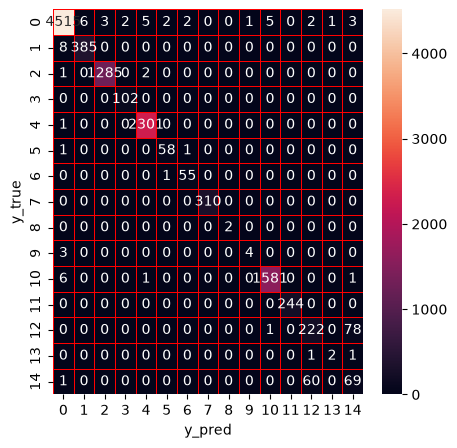

In [53]:
dt = DecisionTreeClassifier(random_state = 0)
dt.fit(X_train,y_train) 
dt_score=dt.score(X_test,y_test)
y_predict=dt.predict(X_test)
y_true=y_test
print('Accuracy of DT: '+ str(dt_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of DT: '+(str(precision)))
print('Recall of DT: '+(str(recall)))
print('F1-score of DT: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [54]:
dt_train=dt.predict(X_train)
dt_test=dt.predict(X_test)

Accuracy of RF: 0.9820026466696075
Precision of RF: 0.9817912109880464
Recall of RF: 0.9820026466696075
F1-score of RF: 0.9818244094603541
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4547
           1       0.99      0.97      0.98       393
           2       1.00      1.00      1.00      1288
           3       0.99      1.00      1.00       102
           4       1.00      1.00      1.00      2302
           5       0.97      0.98      0.98        60
           6       0.98      0.95      0.96        56
           7       1.00      1.00      1.00       310
           8       1.00      1.00      1.00         2
           9       1.00      0.57      0.73         7
          10       1.00      1.00      1.00      1589
          11       1.00      1.00      1.00       244
          12       0.74      0.74      0.74       301
          13       1.00      0.50      0.67         4
          14       0.40      0.38      0.39       

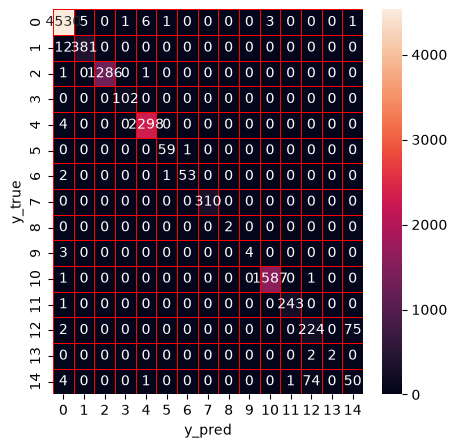

In [55]:
rf = RandomForestClassifier(random_state = 0)
rf.fit(X_train,y_train) # modelin veri üzerinde öğrenmesi fit fonksiyonuyla yapılıyor
rf_score=rf.score(X_test,y_test)
y_predict=rf.predict(X_test)
y_true=y_test
print('Accuracy of RF: '+ str(rf_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of RF: '+(str(precision)))
print('Recall of RF: '+(str(recall)))
print('F1-score of RF: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [56]:
rf_train=rf.predict(X_train)
rf_test=rf.predict(X_test)

Accuracy of ET: 0.980326422584914
Precision of ET: 0.9806479599817856
Recall of ET: 0.980326422584914
F1-score of ET: 0.9804306460775836
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4547
           1       0.98      0.97      0.97       393
           2       1.00      1.00      1.00      1288
           3       0.99      1.00      1.00       102
           4       1.00      1.00      1.00      2302
           5       0.98      0.98      0.98        60
           6       0.96      0.95      0.95        56
           7       1.00      1.00      1.00       310
           8       1.00      1.00      1.00         2
           9       0.80      0.57      0.67         7
          10       1.00      1.00      1.00      1589
          11       1.00      1.00      1.00       244
          12       0.74      0.70      0.72       301
          13       0.50      0.25      0.33         4
          14       0.38      0.42      0.40       13

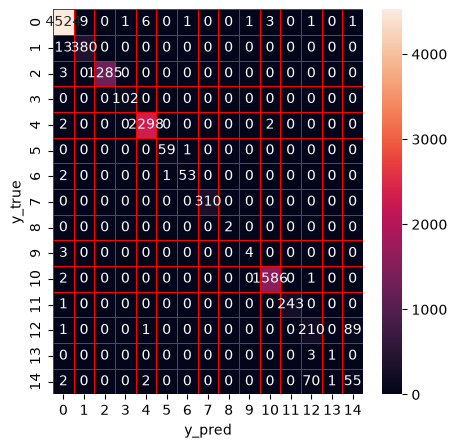

In [57]:
et = ExtraTreesClassifier(random_state = 0)
et.fit(X_train,y_train) 
et_score=et.score(X_test,y_test)
y_predict=et.predict(X_test)
y_true=y_test
print('Accuracy of ET: '+ str(et_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of ET: '+(str(precision)))
print('Recall of ET: '+(str(recall)))
print('F1-score of ET: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [58]:
et_train=et.predict(X_train)
et_test=et.predict(X_test)

Accuracy of XGBoost: 0.9804146449051611
Precision of XGBoost: 0.9821893239111343
Recall of XGBoost: 0.9804146449051611
F1-score of XGBoost: 0.9808159922127644
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4547
           1       0.99      0.97      0.98       393
           2       1.00      1.00      1.00      1288
           3       0.99      0.95      0.97       102
           4       0.99      1.00      1.00      2302
           5       0.89      0.98      0.94        60
           6       0.98      0.91      0.94        56
           7       1.00      1.00      1.00       310
           8       1.00      1.00      1.00         2
           9       1.00      0.57      0.73         7
          10       1.00      1.00      1.00      1589
          11       1.00      1.00      1.00       244
          12       0.79      0.64      0.71       301
          13       1.00      0.50      0.67         4
          14       0.41      0

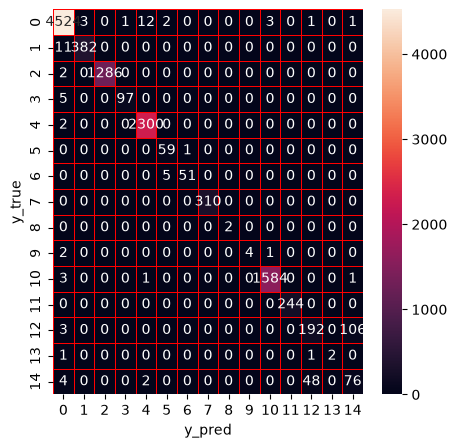

In [59]:
xg = xgb.XGBClassifier(n_estimators = 10)
xg.fit(X_train,y_train)
xg_score=xg.score(X_test,y_test)
y_predict=xg.predict(X_test)
y_true=y_test
print('Accuracy of XGBoost: '+ str(xg_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [60]:
xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)

### Stacking model construction

In [61]:
base_predictions_train = pd.DataFrame( {
    'DecisionTree': dt_train.ravel(),
        'RandomForest': rf_train.ravel(),
     'ExtraTrees': et_train.ravel(),
     'XgBoost': xg_train.ravel(),
    })
base_predictions_train.head(5)

,DecisionTree,RandomForest,ExtraTrees,XgBoost
0,3,3,3,3
1,0,0,0,0
2,2,2,2,2
3,0,0,0,0
4,10,10,10,10


In [62]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)

In [63]:
x_train = np.concatenate(( dt_train, et_train, rf_train, xg_train), axis=1)
x_test = np.concatenate(( dt_test, et_test, rf_test, xg_test), axis=1)

Accuracy of Stacking: 0.9823555359505955
Precision of Stacking: 0.9830497704121741
Recall of Stacking: 0.9823555359505955
F1-score of Stacking: 0.9826333274509066
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4547
           1       0.98      0.98      0.98       393
           2       1.00      1.00      1.00      1288
           3       0.98      1.00      0.99       102
           4       1.00      1.00      1.00      2302
           5       0.95      0.97      0.96        60
           6       0.95      0.98      0.96        56
           7       1.00      1.00      1.00       310
           8       1.00      1.00      1.00         2
           9       0.80      0.57      0.67         7
          10       1.00      0.99      1.00      1589
          11       1.00      1.00      1.00       244
          12       0.78      0.74      0.76       301
          13       0.67      0.50      0.57         4
          14       0.45   

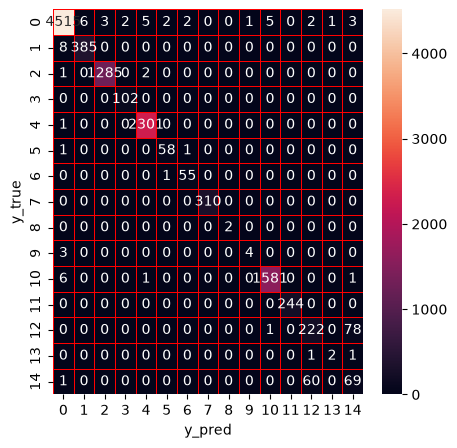

In [64]:
stk = xgb.XGBClassifier().fit(x_train, y_train)
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()